<a href="https://colab.research.google.com/github/harini200614/Data-Visualization-lab/blob/main/lab5_231401033.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded successfully!
  location  year         category  rank  query
0   Global  2001  Consumer Brands     1  Nokia
1   Global  2001  Consumer Brands     2   Sony
2   Global  2001  Consumer Brands     3    BMW
3   Global  2001  Consumer Brands     4   Palm
4   Global  2001  Consumer Brands     5  Adobe

Columns:
['location', 'year', 'category', 'rank', 'query']


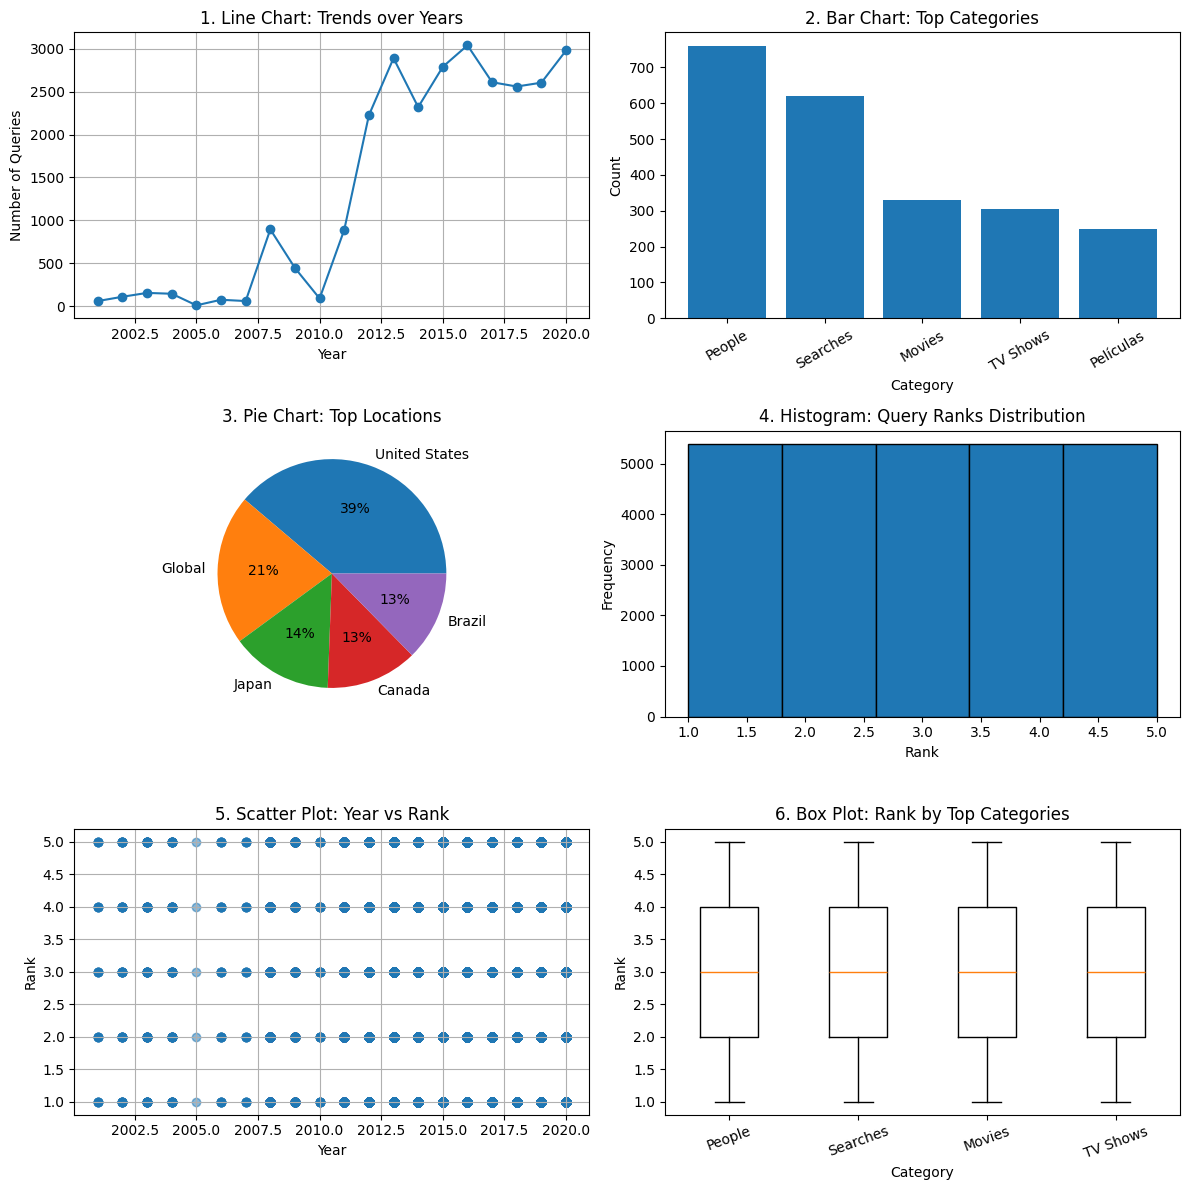

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. LOAD DATASET
# ============================================================

url = "https://raw.githubusercontent.com/tttdddnet/Python-Data-Journalism/main/part1/trends.csv"

df = pd.read_csv(url)

print("Data loaded successfully!")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# 2. SETUP PLOT GRID
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# ============================================================
# CHART 1: LINE CHART
# ============================================================

year_counts = df["year"].value_counts().sort_index()

axes[0, 0].plot(
    year_counts.index,
    year_counts.values,
    marker="o"
)

axes[0, 0].set_title("1. Line Chart: Trends over Years")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Number of Queries")
axes[0, 0].grid(True)

# ============================================================
# CHART 2: BAR CHART
# ============================================================

cat_counts = df["category"].value_counts().head(5)

axes[0, 1].bar(
    cat_counts.index.astype(str),
    cat_counts.values
)

axes[0, 1].set_title("2. Bar Chart: Top Categories")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=30)

# ============================================================
# CHART 3: PIE CHART
# ============================================================

loc_counts = df["location"].value_counts().head(5)

axes[1, 0].pie(
    loc_counts.values,
    labels=loc_counts.index,
    autopct="%1.0f%%"
)

axes[1, 0].set_title("3. Pie Chart: Top Locations")

# ============================================================
# CHART 4: HISTOGRAM
# ============================================================

axes[1, 1].hist(
    df["rank"].dropna(),
    bins=5,
    edgecolor="black"
)

axes[1, 1].set_title("4. Histogram: Query Ranks Distribution")
axes[1, 1].set_xlabel("Rank")
axes[1, 1].set_ylabel("Frequency")

# ============================================================
# CHART 5: SCATTER PLOT
# ============================================================

axes[2, 0].scatter(
    df["year"],
    df["rank"],
    alpha=0.3
)

axes[2, 0].set_title("5. Scatter Plot: Year vs Rank")
axes[2, 0].set_xlabel("Year")
axes[2, 0].set_ylabel("Rank")
axes[2, 0].grid(True)

# ============================================================
# CHART 6: BOX PLOT
# ============================================================

top_cats = df["category"].value_counts().head(4).index

data_by_cat = [
    df[df["category"] == category]["rank"].dropna()
    for category in top_cats
]

axes[2, 1].boxplot(
    data_by_cat,
    tick_labels=top_cats
)

axes[2, 1].set_title("6. Box Plot: Rank by Top Categories")
axes[2, 1].set_xlabel("Category")
axes[2, 1].set_ylabel("Rank")
axes[2, 1].tick_params(axis="x", rotation=20)

# ============================================================
# FINAL DISPLAY
# ============================================================

plt.tight_layout()
plt.show()